In [418]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Тикеры компаний из разных секторов
tickers = ['NVDA', 'GS', 'PFE', 'XOM', 'KO']

# Загружаем данные за 5 лет
print("Загружаем данные...")
data = yf.download(tickers, start='2020-01-01', end='2025-07-01')

# Сохраняем в CSV
data.to_csv('../data/stock_data.csv')
print("Данные сохранены в ../data/stock_data.csv")

# Смотрим, что получилось
print("\nПервые 5 строк:")
print(data.head())
print(f"\nРазмер данных: {data.shape}")

# Словарь для подписей графиков
companies = {'GS' : 'Sachs Group Inc.', 'KO': 'Coca-Cola Company', 'NVDA' : 'NVIDIA Corp.', 'PFE' : 'Pfizer Inc.', 'XOM' : 'ExxonMobil Holdings'}

[*********************100%***********************]  5 of 5 completed

Загружаем данные...
Данные сохранены в ../data/stock_data.csv

Первые 5 строк:
Price            Close                                                   High  \
Ticker              GS         KO      NVDA        PFE        XOM          GS   
Date                                                                            
2020-01-02  202.118896  45.141270  5.963802  27.048357  52.947037  202.394914   
2020-01-03  199.755463  44.894989  5.868347  26.903236  52.521358  200.643915   
2020-01-06  201.799713  44.878582  5.892956  26.868679  52.924637  201.860100   
2020-01-07  203.128098  44.533806  5.964300  26.778843  52.491482  205.094770   
2020-01-08  205.086197  44.615891  5.975487  26.993074  51.699905  206.802729   

Price                                                  ...        Open  \
Ticker             KO      NVDA        PFE        XOM  ...          GS   
Date                                                   ...               
2020-01-02  45.502464  5.963802  27.193482  53.036

In [57]:
# 1. Изучение данных

# общая информация
print(data.info())

#количество дней промежутка
print(f'Диапазон: c {data.index[-1]} по {data.index[0]}, продолжительность: {data.index[-1] - data.index[0]}')

#количество Nanов
print('Количество Nan в каждом столбце:', data.isnull().sum())

<class 'pandas.DataFrame'>
DatetimeIndex: 1380 entries, 2020-01-02 to 2025-06-30
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GS)     1380 non-null   float64
 1   (Close, KO)     1380 non-null   float64
 2   (Close, NVDA)   1380 non-null   float64
 3   (Close, PFE)    1380 non-null   float64
 4   (Close, XOM)    1380 non-null   float64
 5   (High, GS)      1380 non-null   float64
 6   (High, KO)      1380 non-null   float64
 7   (High, NVDA)    1380 non-null   float64
 8   (High, PFE)     1380 non-null   float64
 9   (High, XOM)     1380 non-null   float64
 10  (Low, GS)       1380 non-null   float64
 11  (Low, KO)       1380 non-null   float64
 12  (Low, NVDA)     1380 non-null   float64
 13  (Low, PFE)      1380 non-null   float64
 14  (Low, XOM)      1380 non-null   float64
 15  (Open, GS)      1380 non-null   float64
 16  (Open, KO)      1380 non-null   float64
 17  (Open, NVDA)    1380 non-n

In [3]:
'''
Вывод
Размеры:
    1380 строк
    25 колонок - 5 метрик на 5 компаний
Метрики: 
    Close - стоимость последней сделки с активом 
    High - самая высокая актива цена за период времени
    Low - самая низкая актива цена за период времени
    Open - стоимость первой сделки с активом 
    Volume - общее количество проданных и купленных активов за время формирования одной свечи
Выбранный период времени:
    2020.01.02 - 2025.06.30 включительно, 2006 дней считая не рабочие
Пропущенных значений нет
'''

'\nВывод\nРазмеры:\n    1380 строк\n    25 колонок - 5 метрик на 5 компаний\nМетрики: \n    Close - стоимость последней сделки с активом \n    High - самая высокая актива цена за период времени\n    Low - самая низкая актива цена за период времени\n    Open - стоимость первой сделки с активом \n    Volume - общее количество проданных и купленных активов за время формирования одной свечи\nВыбранный период времени:\n    2020.01.02 - 2025.06.30 включительно, 2006 дней считая не рабочие\nПропущенных значений нет\n'

In [59]:
# 2. Извлечение и визуализация цен закрытия
close_prices = data['Close']
close_prices

Ticker,GS,KO,NVDA,PFE,XOM
Date,,,,,
2020-01-02,202.118896,45.141270,5.963802,27.048357,52.947037
2020-01-03,199.755463,44.894989,5.868347,26.903236,52.521358
2020-01-06,201.799713,44.878582,5.892956,26.868679,52.924637
2020-01-07,203.128098,44.533806,5.964300,26.778843,52.491482
2020-01-08,205.086197,44.615891,5.975487,26.993074,51.699905
...,...,...,...,...,...
2025-06-24,651.904846,68.276360,147.703262,22.722149,104.993210
2025-06-25,659.545227,67.712326,154.104752,22.675415,105.022293
2025-06-26,676.568726,67.556747,154.813797,22.656721,106.592239


In [65]:
# 3-4. Расчёт доходности и её статистический анализ

# Также визуализировал

# Доходность
profit = close_prices.apply(lambda p: (p - p.shift(1, fill_value = 1))/p.shift(-1, fill_value = 1))[1:-1]

# Средняя доходность
mean_profit = profit.mean()

# Среднее отклонение доходности
std_profit = profit.std()

# Минимальная и максимальная дневная доходность
min_profit = profit.min()
max_profit = profit.max()

# Суммарная доходность за весь период
total_profit = (profit + 1).prod()

print("Средняя: ", mean_profit)
print("Отклонение: ", std_profit)
print("Минимальная: ", min_profit)
print("Максимальная: ", max_profit)
print("Суммарная: ", total_profit)

Средняя:  Ticker
GS      0.000687
KO      0.000220
NVDA    0.001898
PFE    -0.000259
XOM     0.000287
dtype: float64
Отклонение:  Ticker
GS      0.021188
KO      0.013201
NVDA    0.034107
PFE     0.017177
XOM     0.021353
dtype: float64
Минимальная:  Ticker
GS     -0.141867
KO     -0.103283
NVDA   -0.204538
PFE    -0.080613
XOM    -0.134300
dtype: float64
Максимальная:  Ticker
GS      0.171279
KO      0.062602
NVDA    0.191085
PFE     0.098490
XOM     0.109936
dtype: float64
Суммарная:  Ticker
GS      1.890089
KO      1.199564
NVDA    6.106422
PFE     0.571229
XOM     1.083252
dtype: float64


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

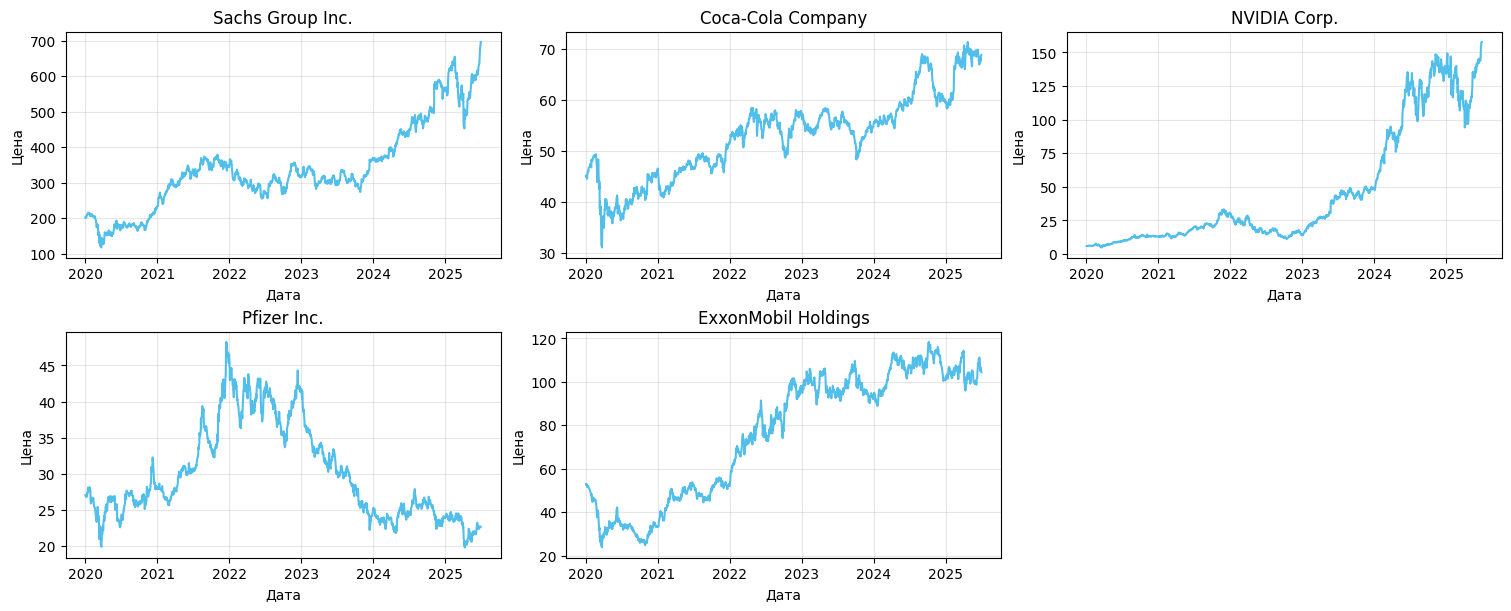

In [422]:
# 5. Визуализация цен (закрытия)

fig, axes = plt.subplots(2, 3, figsize=(15, 6), layout="constrained")

for i in range(5):
    comp = close_prices.columns[i]
    axes[i//3, i%3].plot(close_prices[comp], color='#52bfeb')
    axes[i//3, i%3].set_title(companies[comp])
    axes[i//3, i%3].set_xlabel('Дата')
    axes[i//3, i%3].set_ylabel('Цена')
    axes[i//3, i%3].grid(True, alpha=0.3)
axes[1, 2].axis('off')

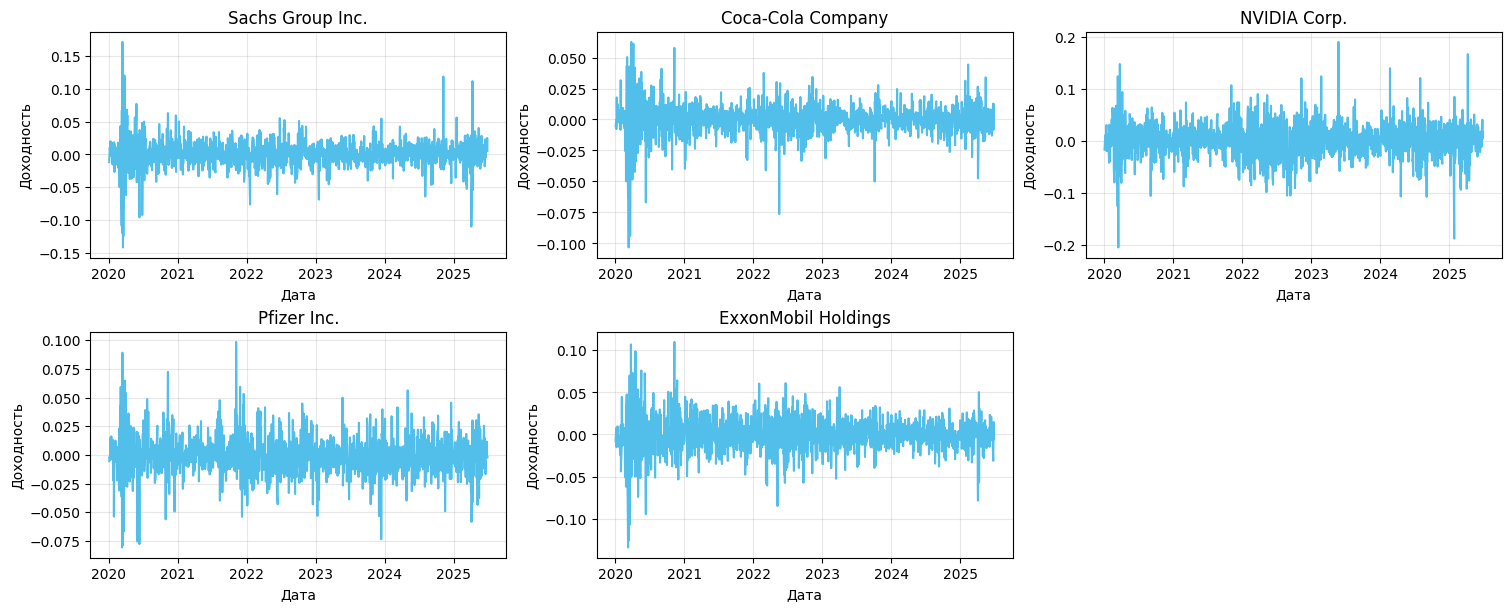

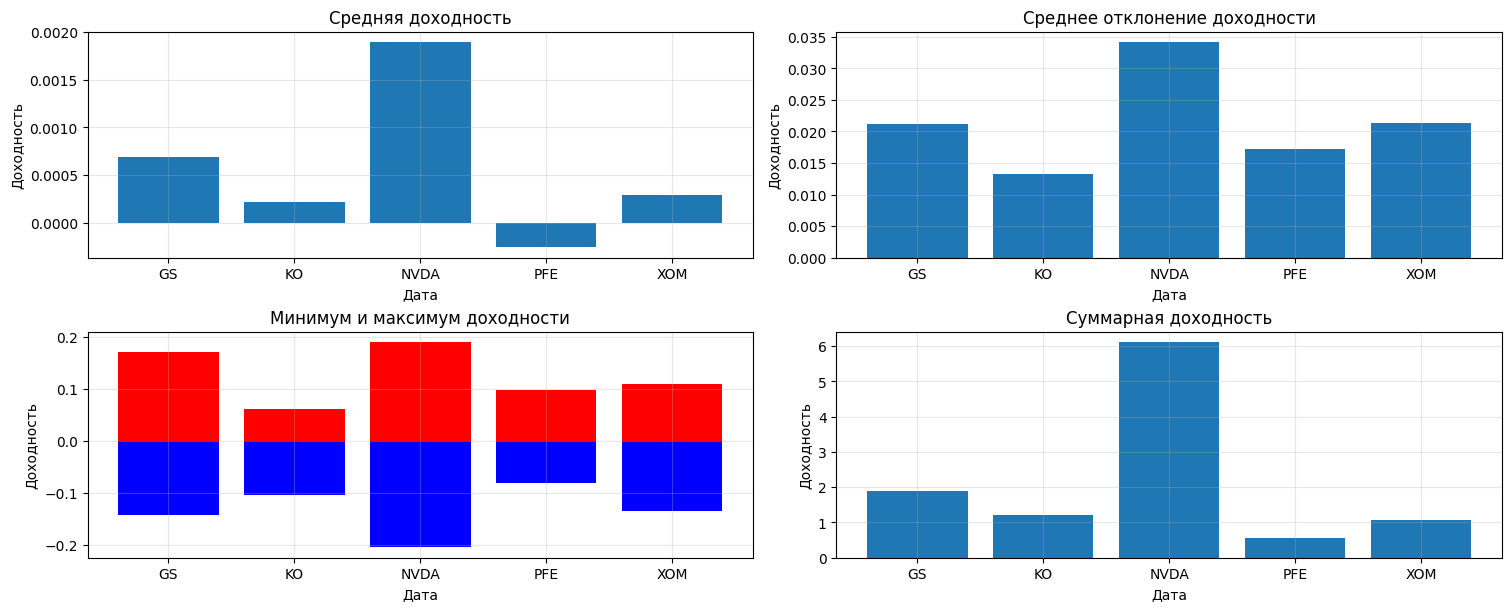

In [425]:
# 6. Визуализация доходности
prof_figure, prof_axes = plt.subplots(2, 3, figsize=(15, 6), layout="constrained")
for i in range(5):
    comp = profit.columns[i]
    prof_axes[i//3, i%3].plot(profit[comp], color='#52bfeb')
    prof_axes[i//3, i%3].set_title(companies[comp])
    prof_axes[i//3, i%3].set_xlabel('Дата')
    prof_axes[i//3, i%3].set_ylabel('Доходность')
    prof_axes[i//3, i%3].grid(True, alpha=0.3)
prof_axes[1, 2].axis('off')

# Среднее
stat_figure, stat_axes = plt.subplots(2, 2, figsize=(15, 6), layout="constrained")
stat_axes[0, 0].bar(mean_profit.index, mean_profit)
stat_axes[0, 0].set_title('Средняя доходность')
stat_axes[0, 0].set_xlabel('Дата')
stat_axes[0, 0].set_ylabel('Доходность')
stat_axes[0, 0].grid(True, alpha=0.3)

# Отклонение
stat_axes[0, 1].bar(std_profit.index, std_profit)
stat_axes[0, 1].set_title('Среднее отклонение доходности')
stat_axes[0, 1].set_xlabel('Дата')
stat_axes[0, 1].set_ylabel('Доходность')
stat_axes[0, 1].grid(True, alpha=0.3)

# Минимум и максимум
stat_axes[1, 0].bar(max_profit.index, max_profit, color = 'red')
stat_axes[1, 0].bar(min_profit.index, min_profit, color = 'blue')
stat_axes[1, 0].set_title('Минимум и максимум доходности')
stat_axes[1, 0].set_xlabel('Дата')
stat_axes[1, 0].set_ylabel('Доходность')
stat_axes[1, 0].grid(True, alpha=0.3)

# Сумма
stat_axes[1, 1].bar(total_profit.index, total_profit)
stat_axes[1, 1].set_title('Суммарная доходность')
stat_axes[1, 1].set_xlabel('Дата')
stat_axes[1, 1].set_ylabel('Доходность')
stat_axes[1, 1].grid(True, alpha=0.3)


Минимальная корреляция 0.1548 между компаниями NVDA, PFE
Максимальная корреляция 0.5419 между компаниями GS, XOM


<Axes: xlabel='Ticker', ylabel='Ticker'>

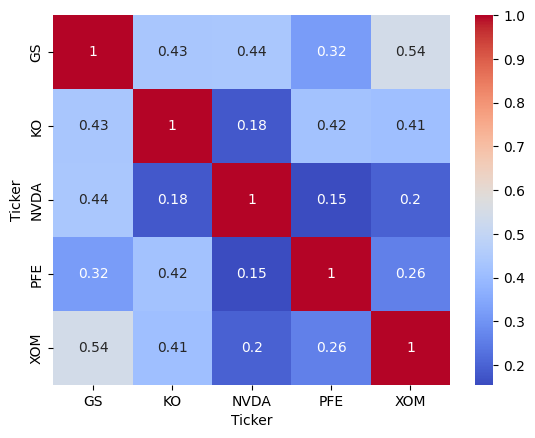

In [104]:
# 7. Корреляционный анализ

corr = profit.corr()
#corr.loc[corr.index == corr.columns] = np.nan
min_comp1 = corr.min().idxmin()
min_comp2 = corr.idxmin()[corr.min().idxmin()]
min_corr = round(corr.min().min(), 4)
max_comp1 = corr[corr < 1].max().idxmax()
max_comp2 = corr[corr < 1].idxmax()[corr[corr < 1].max().idxmax()]
max_corr = round(corr[corr < 1].max().max(), 4)

print(f'Минимальная корреляция {min_corr} между компаниями {min_comp1}, {min_comp2}')
print(f'Максимальная корреляция {max_corr} между компаниями {max_comp1}, {max_comp2}')
sns.heatmap(corr, annot = True, cmap = 'coolwarm')

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

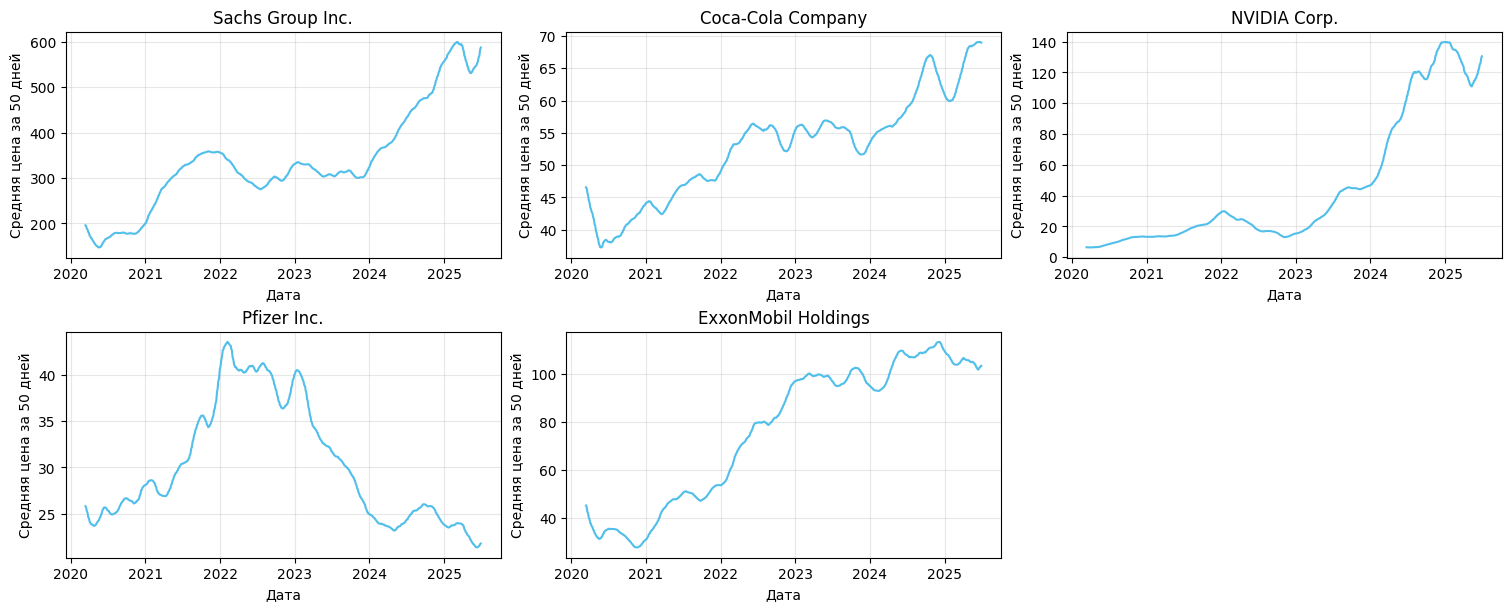

In [426]:
# 8 Скользящее среднее
sliding_mean = close_prices.rolling(window = 50).mean()

slid_figure, slid_axes = plt.subplots(2, 3, figsize=(15, 6), layout="constrained")
for i in range(5):
    comp = sliding_mean.columns[i]
    slid_axes[i//3, i%3].plot(sliding_mean[comp], color='#52bfeb')
    slid_axes[i//3, i%3].set_title(companies[comp])
    slid_axes[i//3, i%3].set_xlabel('Дата')
    slid_axes[i//3, i%3].set_ylabel('Средняя цена за 50 дней')
    slid_axes[i//3, i%3].grid(True, alpha=0.3)
slid_axes[1, 2].axis('off')